In [2]:
import numpy as np
import math
from collections import namedtuple
from tqdm.autonotebook import tqdm
import emcee
from multiprocessing import Pool
# Number of parameters
import matplotlib.pyplot as plt
import os
import re
import pandas as pd
from pathlib import Path

# import own modules
import functions as lf
import radar_functions as rf
import lc_functions as lc
import asteroid_visible_funcs as vis_funcs
from data_structures import ObsData, LightCurve, PartialLightCurve
from mcmc import ln_prob, ln_prior, ln_posterior, theor_curve, ln_wrapper, ln_prob_both, ln_prob_radar
from scipy.optimize import minimize, differential_evolution

In [3]:
# get state vectors of the Earth and the Sun from JPL Horizons database
asteroid_name = "2000 WO107"
lightcurve = LightCurve()  # container to store partial lightcurves
earth_data = ObsData()     # store earth vectors
sun_data = ObsData()       # store sun vectors
# get names of the lightcurve files
directory_lc = 'lightcurves/lc_krug_warner'
#read warner data in csv format
fnames_warner = [f for f in os.listdir(directory_lc) if re.match(r'.*\.csv', f)]
fnames_warner.sort()
for idx, fname in enumerate(fnames_warner):
    # read the base time of the partial lightcurve
    part_curve = pd.read_csv(f'{directory_lc}/{fname}')#, header=None, names=['epoch', 'ut_time', 'mag', 'mag_err'], skiprows=3, sep=' ')
    part_curve['epoch'] = part_curve['epoch'].astype(float)
    part_curve.astype(float)
    part_curve['mag_err'] *= 3
    lightcurve += PartialLightCurve(part_curve, fname=Path(fname).stem)

fnames = [f for f in os.listdir(directory_lc) if re.match(r'.*\.DAT', f)]
fnames.sort()
# read and parse partial lightcurve files
for idx, fname in enumerate(fnames):
    # read the base time of the partial lightcurve
    part_curve = pd.read_csv(f'{directory_lc}/{fname}', header=None, names=['epoch', 'ut_time', 'mag', 'mag_err'], skiprows=3, sep=' ')
    part_curve['epoch'] = part_curve['epoch'].astype(float)
    part_curve.astype(float)
    lightcurve += PartialLightCurve(part_curve, fname=Path(fname).stem)

# sort lightcurves in the ascending order of the epoch
lightcurve.sort_lightcurves()
start_epoch = lightcurve.joined['epoch'].min()
reduc_epochs = lightcurve.joined['epoch'] - start_epoch
for i in range(len(lightcurve)):
    lightcurve.lightcurves[i].data['weight'] = (lightcurve.lightcurves[i].data['weight']
                                                / len(lightcurve.lightcurves[i]) * (len(lightcurve.joined) / len(lightcurve)))

In [4]:
lightcurve.joined

,epoch,ut_time,mag,mag_err,weight,curve_idx
0,2.459182e+06,19.9177,13.016,0.057,1.0,0
1,2.459182e+06,19.9265,12.959,0.060,1.0,0
2,2.459182e+06,19.9354,12.987,0.063,1.0,0
3,2.459182e+06,19.9443,13.047,0.070,1.0,0
4,2.459182e+06,19.9532,13.104,0.070,1.0,0
...,...,...,...,...,...,...
2784,2.459196e+06,NaN,16.818,0.096,1.0,20
2785,2.459196e+06,NaN,16.888,0.135,1.0,20
2786,2.459196e+06,NaN,16.965,0.153,1.0,20
2787,2.459196e+06,NaN,16.956,0.102,1.0,20


In [5]:
# query JPL Horizons to get state vectors of the Sun and the Earth
for part_curve in tqdm(lightcurve, total=len(lightcurve), desc='Querying JPL Horizons'):
    epochs = part_curve.data.epoch.to_list()
    state_vecs_sun = lf.get_object_orbit(asteroid_name, epochs=epochs,  location='@10', data_type='vectors').reset_index(drop=True)
    # @399 - Earth
    state_vecs_earth = lf.get_object_orbit(asteroid_name, epochs=epochs,  location='@399', data_type='vectors').reset_index(drop=True)
    # calculate reduc epoch (counting from start epoch)
    # calculate distance between the Earth and the asteroid
    state_vecs_earth['distance'] = (state_vecs_earth['x']**2 + state_vecs_earth['y']**2 + state_vecs_earth['z']**2)**0.5
    # calulate lighttime (in AU)
    state_vecs_earth['lighttime'] = state_vecs_earth['distance'] / 86400 / 299792458 * 149597870700
    state_vecs_sun['reduc_epoch'] = state_vecs_sun['epoch'] - start_epoch
    state_vecs_earth['reduc_epoch'] = state_vecs_earth['epoch'] - start_epoch  - state_vecs_earth['lighttime']
    # inverse signs of vectors
    state_vecs_sun[['x', 'y', 'z']] = -state_vecs_sun[['x', 'y', 'z']]
    state_vecs_earth[['x', 'y', 'z']] = -state_vecs_earth[['x', 'y', 'z']]
    sun_data += state_vecs_sun
    earth_data += state_vecs_earth

Querying JPL Horizons:   0%|          | 0/21 [00:00<?, ?it/s]

In [6]:
radar_image_params = rf.RadarImageParameters("radar_data/data.txt")
# radar_images_obs = [np.array(read_observed_radar_image(radar_image_params,idx_img)) for idx_img in range(radar_image_params.N_points)]
radar_images_obs = [rf.denoise_img(np.array(rf.read_observed_radar_image(radar_image_params,idx_img)))
                    for idx_img in range(radar_image_params.N_points)]


query_dates = [radar_image_params.jd[idx_img] + 2400000.5 for idx_img in range(len(radar_image_params.jd))]
state_vecs_earth = lf.get_object_orbit('2000 WO107', epochs=query_dates,  location='@399', data_type='vectors')
state_vecs_earth['r'] = np.sum(state_vecs_earth[['x', 'y', 'z']] ** 2, axis=1)**0.5
position_vecs = (state_vecs_earth[['x', 'y', 'z']].T / state_vecs_earth['r']).T
#position_vecs.to_csv('input_data/position_vecs.csv', index=False)

In [7]:
position_vecs

,x,y,z
0,-0.729225,0.680994,-0.066913
1,-0.726683,0.683738,-0.066594
2,-0.724127,0.686475,-0.066272
3,-0.721559,0.689205,-0.065950
4,-0.718977,0.691929,-0.065626
...,...,...,...
66,0.073384,0.996997,0.024718
67,0.075563,0.996829,0.024949
68,0.077726,0.996657,0.025179
69,0.079887,0.996480,0.025408


In [14]:
params = [1.4103, 0.8306, 0.8291, 1.0406, 1.0396, 0.3798, 1.4099, -1.3903, 1.6836, 0.2091, 2476.7444, 2.0162]

In [17]:
a1, b1, c1, a2, b2, c2, lon, lat, init_phase, rot_period = params[:10]
# create two ellipsoids with specified parameters
ellips1 = lc.Ellipsoid(a=a1, b=b1, c=c1)
ellips2 = lc.Ellipsoid(a=a2, b=b2, c=c2)
body = lc.Body(ellips1, ellips2, distance=a1 + a2,
                 eq_latitude=lat,
                 eq_longitude=lon,
                 init_phase=init_phase, rotation_period=rot_period)

In [19]:
rot_earth_data = lc.rotate_vector(body, earth_data.joined)

In [53]:
def theor_curve_vis(params: tuple, earth_data: ObsData, sun_data: ObsData) -> ObsData:
    """builds theoretical lightcurve for the given parameters"""
    a1, b1, c1, a2, b2, c2, lon, lat, init_phase, rot_period = params
    # create two ellipsoids with specified parameters
    ellips1 = lc.Ellipsoid(a=a1, b=b1, c=c1)
    ellips2 = lc.Ellipsoid(a=a2, b=b2, c=c2)
    # create body from two ellipsis
    body = vis_funcs.Body(ellips1, ellips2, distance=a1 + a2,
                     eq_latitude=lat,
                     eq_longitude=lon,
                     init_phase=init_phase, rotation_period=rot_period)
    # create object to store theoretical curve data
    theor_mag_data = ObsData()
    # calculate theoretical lightcurve for every part of the lightcurve
    # compare with the observed, and calculate the necessary shift up/down
    for part_idx, part_curve in enumerate(earth_data):
        # transform vectors asteroid body-fixed frame coords
        vecs_sun_rot = vis_funcs.rotate_vector(body, sun_data[part_idx]).to_numpy()
        vecs_earth_rot = vis_funcs.rotate_vector(body, earth_data[part_idx]).to_numpy()
        brightness = body.total_brightness(sun_vecs=vecs_sun_rot, earth_vecs=vecs_earth_rot)
        # transform to magnitudes
        mag_theor = -2.5 * np.log10(brightness)
        theor_mag_data += mag_theor
    return theor_mag_data

In [54]:
fit_curve = theor_curve_vis(params[:10], earth_data, sun_data)

/tmp/ipykernel_25219/3501661678.py:22: RuntimeWarning: divide by zero encountered in log10
  mag_theor = -2.5 * np.log10(brightness)


In [63]:
a1, b1, c1, a2, b2, c2, lon, lat, init_phase, rot_period = params[:10]
# create two ellipsoids with specified parameters
ellips1 = lc.Ellipsoid(a=a1, b=b1, c=c1)
ellips2 = lc.Ellipsoid(a=a2, b=b2, c=c2)
# create body from two ellipsis
body = vis_funcs.Body(ellips1, ellips2, distance=a1 + a2,
                 eq_latitude=lat,
                 eq_longitude=lon,
                 init_phase=init_phase, rotation_period=rot_period)

In [88]:
part_idx = 0
vecs_sun_rot = vis_funcs.rotate_vector(body, sun_data[part_idx]).to_numpy()
vecs_earth_rot = vis_funcs.rotate_vector(body, earth_data[part_idx]).to_numpy()
print(vecs_sun_rot[0], vecs_earth_rot[0])
brightness = body.component_brightness(sun_vecs=vecs_sun_rot[0:2], earth_vecs=vecs_earth_rot[0:2])

[ 0.10505674 -0.97428804 -0.17662443] [-0.02627392 -0.01204437 -0.00477984]


In [90]:
brightness.shape

(20, 40, 2)

In [94]:
N_radar_pixels = 90
pos = vecs_sun_rot
e_vecs = vecs_earth_rot
brightness_arr = np.zeros((N_radar_pixels, N_radar_pixels))
pos = np.array(ellips1.surface, copy=True)
pos[0] += component.distance

Ny = np.int_(0.5 + 0.5 * N_radar_pixels
             - (pos[0] * e_vecs[0] + pos[1] * e_vecs[1] + pos[2] * e_vecs[2]) / dr / 2)
Nx = np.int_(0.5 + 0.5 * N_radar_pixels
             + 2 * NU0 / C_MS / dnu * 2 * np.pi / P / 84600 * (pos[0] * e_vecs[1] - pos[1] * e_vecs[0] ))
additional_brightness_primary = pixel_brightness_vec(body, e_vecs, pow_coeff=pow_coeff, switch_places=switch_places)

mask = (additional_brightness_primary > 0) & (Nx >= 0) & (Nx < N_radar_pixels) & (Ny >= 0) & (Ny < N_radar_pixels)
np.add.at(brightness_arr, (Ny[mask], Nx[mask]), additional_brightness_primary[mask])

[45 45 45] [45 45 45]


ValueError: array is not broadcastable to correct shape

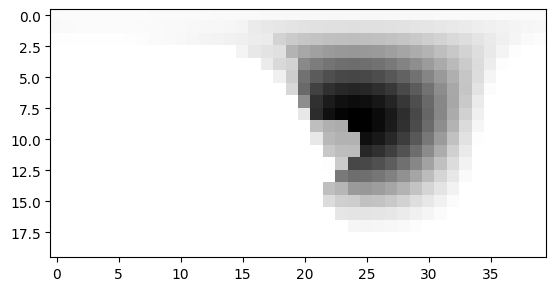

In [87]:
plt.imshow(brightness[:, :, 0], interpolation='nearest', cmap='gray_r')

In [15]:
full_opt_results = np.array(lf.read_bootstrap_from_file('data/radar_only_full_data.txt'))

In [16]:
quant = 0.1
full_opt_results = full_opt_results[np.where(full_opt_results[:, 12] <= np.quantile(full_opt_results[:, 12], q=quant))]

In [24]:
def build_lc_plots(lightcurve, sun_data, lightcurve_theor, num_rows: int, num_cols: int, figsize: tuple = (9, 4.5),
                   dpi: int = 100, show_lc_names=False, plot_errs=False):
    """Builds the plots for the lightcurves"""
    plt.rcParams['figure.facecolor'] = 'white'
    plt.rcParams['axes.labelsize'] = 18
    plt.rcParams['xtick.labelsize'] = 16
    plt.rcParams['ytick.labelsize'] = 16
    plt.rcParams['axes.titlesize'] = 15
    fig, axarr = plt.subplots(num_rows, num_cols, figsize=(figsize[0] * num_cols, figsize[1] * num_rows), dpi=dpi)
    for idx in range(0, len(lightcurve.lightcurves)):
        lc = lightcurve.lightcurves[idx].data
        idx_row, idx_col = idx // num_cols, idx % num_cols
        axarr[idx_row][idx_col].scatter(sun_data[idx]['reduc_epoch'], -lightcurve_theor[idx], s=8,
                                               label='model')
        if plot_errs:
            axarr[idx_row][idx_col].errorbar(sun_data[idx]['reduc_epoch'], -lightcurve.lightcurves[idx].data['mag_shifted'],
                                            yerr=lightcurve.lightcurves[idx].data['mag_err'], label='obs', fmt='.', color='tab:orange')
        else:
            axarr[idx_row][idx_col].scatter(sun_data[idx]['reduc_epoch'],
                                                   -lightcurve.lightcurves[idx].data['mag_shifted'], s=8, label='obs')
        axarr[idx_row][idx_col].set_xlabel('reduc_epoch [days]')
        axarr[idx_row][idx_col].set_ylabel('H [mag]')
        axarr[idx_row][idx_col].legend(loc='upper left', prop={"size": 15})
        if show_lc_names:
            axarr[idx_row][idx_col].annotate(lightcurve.lightcurves[idx].fname, xy=(0.97, 0), xycoords='axes fraction',
                                              xytext=(5, 5), textcoords='offset points', ha='right', va='bottom',
                                             fontproperties={'size': 12, 'weight': 'bold'})
        # Set x-labels to be formatted with two decimal places
        xlabels = [f'{x:.2f}' for x in axarr[idx_row][idx_col].get_xticks()]
        axarr[idx_row][idx_col].set_xticklabels(xlabels)

    return fig, axarr

In [33]:
best_params = list([float(val) for val in full_opt_results[4]])
lightcurve_theor = theor_curve(params=best_params[:10], earth_data=earth_data, sun_data=sun_data)
# calculate how much the part of the observational curve have to be shifted up/down
lightcurve.calculate_shifts(other=lightcurve_theor)
# shift observed data (lightcurves) by the amount of vertical shift
lightcurve.shift_curves()

/tmp/ipykernel_64647/1583389183.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axarr[idx_row][idx_col].set_xticklabels(xlabels)
/tmp/ipykernel_64647/1583389183.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axarr[idx_row][idx_col].set_xticklabels(xlabels)
/tmp/ipykernel_64647/1583389183.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axarr[idx_row][idx_col].set_xticklabels(xlabels)
/tmp/ipykernel_64647/1583389183.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axarr[idx_row][idx_col].set_xticklabels(xlabels)
/tmp/ipykernel_64647/1583389183.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. afte

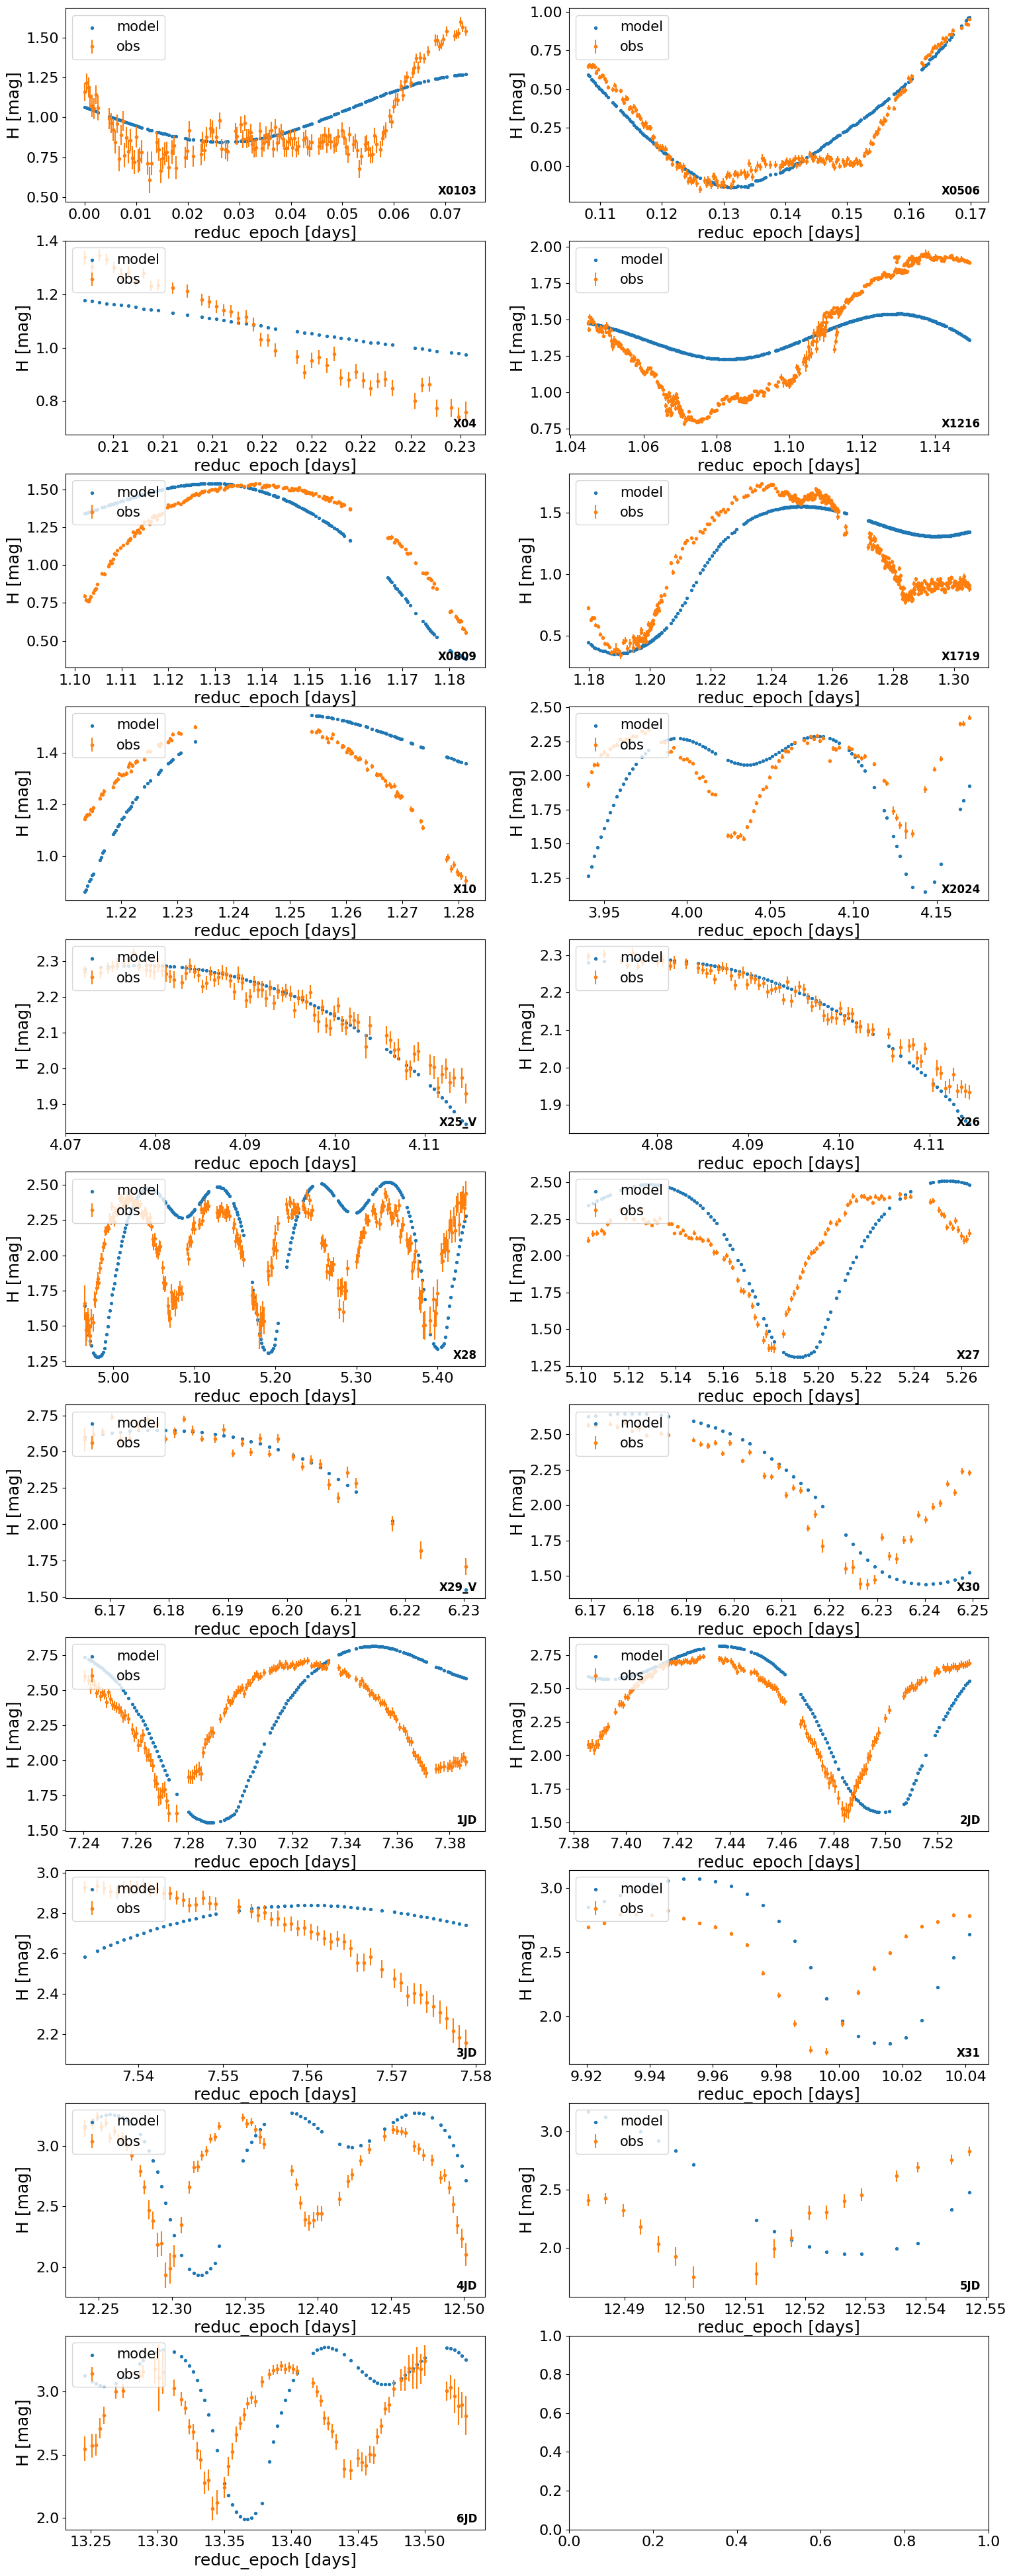

In [34]:
fig, ax = build_lc_plots(lightcurve, sun_data, lightcurve_theor, dpi=100, num_cols=2, num_rows=11, show_lc_names=True, plot_errs=True)

In [25]:
def calculate_phase(reduc_epochs, params):
    init_phase = params[8]  # Assuming init_phase is the 9th parameter
    rot_period = params[9]  # Assuming rot_period is the 10th parameter

    # Calculate time elapsed since the initial phase
    # You might need to adjust this if your init_phase is not given in JD

    # Calculate the number of full rotations
    num_rotations = reduc_epochs / rot_period

    # Calculate the current phase
    current_phase = (init_phase + (num_rotations % 1) * 360) % 360

    return current_phase

In [27]:
phases = calculate_phase(reduc_epochs=reduc_epochs, params=params)

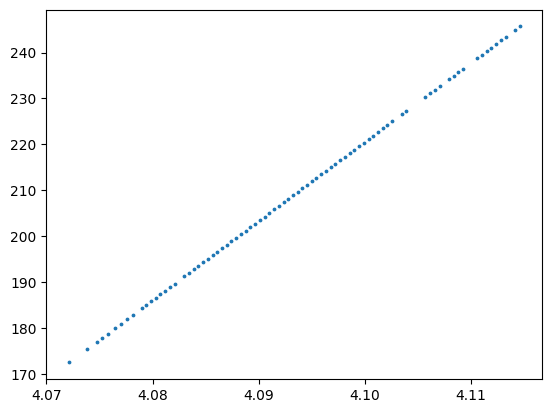

In [49]:
# get the index of the current partial lightcurve
idx = 8
idxes = lightcurve.joined[lightcurve.joined['curve_idx'] == idx].indexplt.scatter(reduc_epochs[idxes], phases[idxes], s=3)

(array([128., 107.,  86.,  97., 113.,  95., 105., 108.,  81.,  52.,  66.,
         82.,  64.,  54.,  67.,  73.,  58.,  68.,  71.,  81.,  76.,  87.,
         83.,  92.,  79.,  63., 102.,  71.,  61.,  58.,  64.,  51.,  44.,
         52.,  69.,  81.]),
 array([1.34102555e-01, 1.01302766e+01, 2.01264507e+01, 3.01226248e+01,
        4.01187989e+01, 5.01149730e+01, 6.01111471e+01, 7.01073212e+01,
        8.01034953e+01, 9.00996693e+01, 1.00095843e+02, 1.10092018e+02,
        1.20088192e+02, 1.30084366e+02, 1.40080540e+02, 1.50076714e+02,
        1.60072888e+02, 1.70069062e+02, 1.80065236e+02, 1.90061410e+02,
        2.00057584e+02, 2.10053758e+02, 2.20049932e+02, 2.30046107e+02,
        2.40042281e+02, 2.50038455e+02, 2.60034629e+02, 2.70030803e+02,
        2.80026977e+02, 2.90023151e+02, 3.00019325e+02, 3.10015499e+02,
        3.20011673e+02, 3.30007847e+02, 3.40004022e+02, 3.50000196e+02,
        3.59996370e+02]),
 <BarContainer object of 36 artists>)

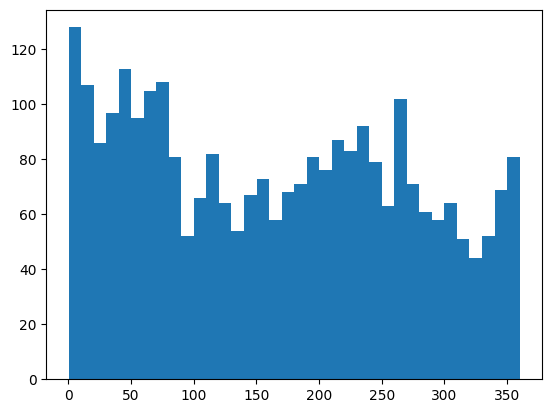

In [51]:
plt.hist(phases, bins=36)